In [14]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path

#checkpoints = {
#    "MultVAE + L2": "TopKSAE-8192-f634db83.ckpt",
#    "ELSA + L2": "TopKSAE-8192-d6337b64.ckpt",
#    "ELSA + Cosine": "TopKSAE-8192-3c29e9ee.ckpt",    
#}

checkpoints = {
    "MultVAE + L2": "TopKSAE-8192-b457e403.ckpt",
    "ELSA + L2": "TopKSAE-8192-c347146b.ckpt",
    "ELSA + Cosine": "TopKSAE-8192-7420ec46.ckpt",
    "TEASER-GD": "TEASERGD-1633-27bfcdb4.ckpt",
}


# From Neurons to Tags

In [15]:
from scipy.stats import entropy

from datasets import prepare_interaction_data
from teaser import load_item_tag_matrix
from util import CHECKPOINT_FOLDER, load_config_from_checkpoint


def compute_tfidf(X):
    tf = X / np.sum(X, axis=0, keepdims=True)
    tf[np.isnan(tf)] = 0
    df = np.count_nonzero(X, axis=1)
    num_documents = X.shape[1]
    idf = np.log((num_documents + 1) / (df + 1)) + 1
    return tf * idf[:, np.newaxis]


def ensure_teaser_interpretability_csvs(checkpoint):
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    neuron_path = Path(f"results/res_neuron_tag_{chckpt_name}.csv")
    tag_path = Path(f"results/res_tag_neuron_{chckpt_name}.csv")
    if neuron_path.exists() and tag_path.exists():
        return

    cfg = load_config_from_checkpoint(f"{CHECKPOINT_FOLDER}/ML-25M/{checkpoint}")
    _, _, _, _, _, train_users, _, items = prepare_interaction_data(cfg)
    item_tag_matrix, tags = load_item_tag_matrix(cfg["dataset"], items, cfg["tag_min_count"], weighted=False)
    item_tag = item_tag_matrix.numpy()
    tag_item_counts = item_tag.T.astype(np.float64)
    pti = tag_item_counts.copy()
    pti /= pti.sum()
    tag_neuron_activity = pti @ item_tag

    epsilon = 1e-9

    normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity.T)
    mean_neuron_activity = normalized_tag_neuron_activity.sum(axis=0)
    valid_neurons = []
    neuron_entropy = []
    neuron_kl_div = []
    for n in range(normalized_tag_neuron_activity.shape[0]):
        neuron_tag_activation = normalized_tag_neuron_activity[n, :]
        if neuron_tag_activation.sum() > 0:
            n_entropy = entropy(neuron_tag_activation)
            neuron_tag_activation = neuron_tag_activation.copy() + epsilon
            n_kl_div = entropy(mean_neuron_activity, neuron_tag_activation)
            valid_neurons.append(n)
            neuron_entropy.append(n_entropy)
            neuron_kl_div.append(n_kl_div)
    res = pd.DataFrame({"id": valid_neurons, "entropy": neuron_entropy, "KL_div": neuron_kl_div})
    res["norm_entropy_diff"] = (entropy(mean_neuron_activity) - res.entropy) / entropy(mean_neuron_activity)
    res.to_csv(neuron_path)

    normalized_tag_neuron_activity = compute_tfidf(tag_neuron_activity).T
    mean_tag_activity = normalized_tag_neuron_activity.sum(axis=1)
    valid_tags = []
    tag_entropy = []
    tag_kl_div = []
    for t in range(normalized_tag_neuron_activity.shape[1]):
        neuron_tag_activation = normalized_tag_neuron_activity[:, t]
        if neuron_tag_activation.sum() > 0:
            n_entropy = entropy(neuron_tag_activation)
            neuron_tag_activation = neuron_tag_activation.copy() + epsilon
            n_kl_div = entropy(mean_tag_activity, neuron_tag_activation)
            valid_tags.append(t)
            tag_entropy.append(n_entropy)
            tag_kl_div.append(n_kl_div)
    res = pd.DataFrame({"id": valid_tags, "tag": tags[valid_tags], "entropy": tag_entropy, "KL_div": tag_kl_div})
    res["norm_entropy_diff"] = (entropy(mean_tag_activity) - res.entropy) / entropy(mean_tag_activity)
    res.to_csv(tag_path)


results = {}
resultsT_to_N = {}
for model, checkpoint in checkpoints.items():
    if checkpoint.startswith("TEASERGD"):
        ensure_teaser_interpretability_csvs(checkpoint)
    chckpt_name = checkpoint.split("-", 1)[1].replace(".ckpt", "")
    results[model] = pd.read_csv(f"results/res_neuron_tag_{chckpt_name}.csv")
    resultsT_to_N[model] = pd.read_csv(f"results/res_tag_neuron_{chckpt_name}.csv")


Removing users with < 5 interactions...
Dataset info: users=160776, items=40857, interactions=12448242
Train split info: users=128621, items=40857, interactions=10002246
Val split info: users=16078, items=40857, interactions=1239095
Test split info: users=16077, items=40857, interactions=1206901


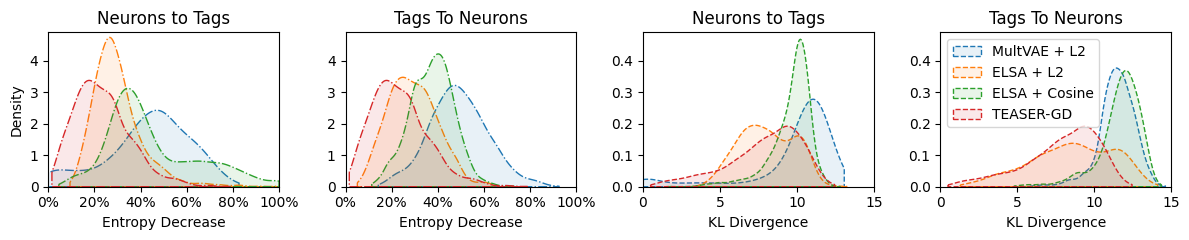

In [16]:
# Initialize the plot
fig, (ax1,ax3,ax2,ax4) = plt.subplots(1,4, figsize=(12, 2.5))
for model, res in results.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax2, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax1, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("")
ax2.set_xlabel("")
ax1.set_ylabel("Density (Normalized Entropy Diff)")
ax2.set_ylabel("Density (KL divergence)")


for model, res in resultsT_to_N.items():
    min_kldiv = res['KL_div'].min()
    max_kldiv = res['KL_div'].max()
    sns.kdeplot(res["KL_div"], ax=ax4, label=model, fill=True, linestyle="--", clip=(min_kldiv, max_kldiv), alpha=0.1)


    min_entropy = res['norm_entropy_diff'].min()
    max_entropy = res['norm_entropy_diff'].max()
    sns.kdeplot(res["norm_entropy_diff"], ax=ax3, label=model, fill=True, linestyle="-.", clip=(min_entropy, max_entropy), alpha=0.1)

ax1.set_xlabel("Entropy Decrease")
ax2.set_xlabel("KL Divergence")
ax3.set_xlabel("Entropy Decrease")
ax4.set_xlabel("KL Divergence")

ax1.set_ylabel("Density")
ax2.set_ylabel("")
ax3.set_ylabel("")
ax4.set_ylabel("")

ax1.set_title("Neurons to Tags")
ax2.set_title("Neurons to Tags")
ax3.set_title("Tags To Neurons")
ax4.set_title("Tags To Neurons")

ax1.set_xlim(0.0, 1.0)
ax1.set_ylim(0.0, 4.9)
ax3.set_xlim(0.0, 1.0)
ax3.set_ylim(0.0, 4.9)

ax2.set_xlim(0.0, 15)
ax2.set_ylim(0.0, 0.49)
ax4.set_xlim(0.0, 15)
ax4.set_ylim(0.0, 0.49)

# Show the legend
ax4.legend(loc="upper left")
fig.tight_layout()


ax1.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax1.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels
ax3.set_xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])  # Positions of the ticks
ax3.set_xticklabels(["0%", "20%", "40%", "60%", "80%", "100%"])  # Custom labels

plt.tight_layout()
plt.savefig("results/figures/neuron_interpretability_ML-25M.pdf",bbox_inches='tight', dpi=600)

In [4]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("KL_div", ascending=False)
    dt = pd.concat([res.head(5)[["tag","entropy","KL_div"]],res.tail(1)[["tag","entropy","KL_div"]]])
    print(model)
    print(dt.to_latex(index=False, float_format="{:.2f}".format))



ELSA + Cosine
\begin{tabular}{lrr}
\toprule
tag & entropy & KL_div \\
\midrule
quentin tarantino & 4.56 & 14.36 \\
coen brothers & 5.05 & 14.10 \\
james bond & 4.85 & 13.97 \\
jim carrey & 4.95 & 13.94 \\
studio ghibli & 4.75 & 13.94 \\
bd-r & 7.58 & 4.77 \\
\bottomrule
\end{tabular}



In [5]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    dt = res.head(1)[["tag","entropy","norm_entropy_diff"]]
    print(model)
    print(dt)
    print(dt.entropy/(1-dt.norm_entropy_diff))

ELSA + Cosine
                tag   entropy  norm_entropy_diff
61  based on a book  7.850811           0.113711
61    8.858073
dtype: float64


In [6]:
for model, res in results.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

ELSA + Cosine
0.44884605180663856 9.632678055436001


In [7]:
for model, res in resultsT_to_N.items():
    res = res.sort_values("entropy", ascending=False)
    print(model)
    print(res.norm_entropy_diff.mean(),res.KL_div.mean())

ELSA + Cosine
0.3743131682162623 11.650445333835172


In [8]:
for model, res in resultsT_to_N.items():
    print(model)
    print((res.KL_div>10).sum() / res.shape[0])


ELSA + Cosine
0.893447642375995
